# Очистка данных кафе

Здесь будет описание проекта.

In [51]:
import re

In [52]:
%pip freeze > requirements.txt
import pandas as pd


# Используем "Raw" ссылку (обязательно слово raw.githubusercontent.com)
url = 'https://raw.githubusercontent.com/peneeeee1/junior-analyst-portfolio/main/cafe-data-cleaning/dirty_cafe_sales.csv'
df_before= pd.read_csv(url)
df = pd.read_csv(url)

# Знакомство с данными (первичное)
print(df.head(20))
print(df.info())
print(df.describe())

#Удаляю стобец Total Spent, так как неудобен для  рассчетов в витрине
df_new = df.drop(columns=['Total Spent'])








   Transaction ID      Item Quantity Price Per Unit Total Spent  \
0     TXN_1961373    Coffee        2            2.0         4.0   
1     TXN_4977031      Cake        4            3.0        12.0   
2     TXN_4271903    Cookie        4            1.0       ERROR   
3     TXN_7034554     Salad        2            5.0        10.0   
4     TXN_3160411    Coffee        2            2.0         4.0   
5     TXN_2602893  Smoothie        5            4.0        20.0   
6     TXN_4433211   UNKNOWN        3            3.0         9.0   
7     TXN_6699534  Sandwich        4            4.0        16.0   
8     TXN_4717867       NaN        5            3.0        15.0   
9     TXN_2064365  Sandwich        5            4.0        20.0   
10    TXN_2548360     Salad        5            5.0        25.0   
11    TXN_3051279  Sandwich        2            4.0         8.0   
12    TXN_7619095  Sandwich        2            4.0         8.0   
13    TXN_9437049    Cookie        5            1.0         5.

['TXN_1961373' 'TXN_4977031' 'TXN_4271903' ... 'TXN_5255387' 'TXN_7695629'
 'TXN_6170729']
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']
['2' '4' '5' '3' '1' 'ERROR' 'UNKNOWN' nan]
['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN']
['4.0' '12.0' 'ERROR' '10.0' '20.0' '9.0' '16.0' '15.0' '25.0' '8.0' '5.0'
 '3.0' '6.0' nan 'UNKNOWN' '2.0' '1.0' '7.5' '4.5' '1.5']
['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]
['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']
['2023-09-08' '2023-05-16' '2023-07-19' '2023-04-27' '2023-06-11'
 '2023-03-31' '2023-10-06' '2023-10-28' '2023-07-28' '2023-12-31'
 '2023-11-07' 'ERROR' '2023-05-03' '2023-06-01' '2023-03-21' '2023-11-15'
 '2023-06-10' '2023-02-24' '2023-03-25' '2023-01-15' '2023-04-04'
 '2023-03-30' '2023-12-01' '2023-09-18' '2023-06-03' '2023-12-13'
 '2023-04-20' '2023-04-10' '2023-03-11' '2023-06-02' '2023-11-06'
 '2023-08-15' '2023-10-09' '2023-05-28' '2023-07-17' '2023-04-29'


"Итого: проделана в меру детальная работа по поиску дублей, но обнаружить их не удалось,\nлибо руководитель ошибся и дублей в данных нет, либо нужно делать более детальный осмотр для\nпоиска.Возможно дубли связаны с наличием в таблице одноверменно и 'UNKNOWN' 'ERROR' и nan"

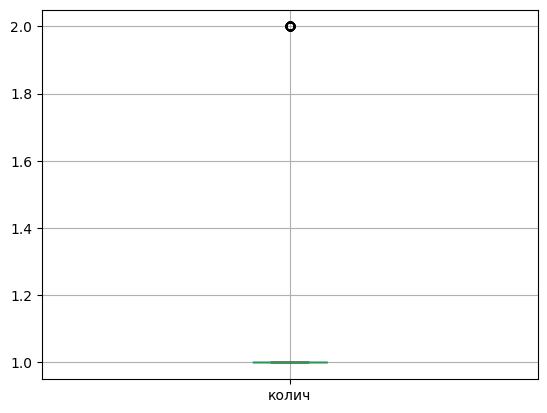

In [53]:
#Работа с дубликатами:
#Просмотр через цикл дублей в названии:

for col in df.columns:
    unique_values = df[col].unique()
    print(unique_values)

"""Полных дублей нет так как id полность уник., в названиях нет(была проверка через цикл),частичные найти
проблематично т.к нет мерила их выявления(ключа). Возможно в стобце с id присутствуют строки не id которые
могут скрыть полные дубликаты."""

#Просмотр наличия уник. значений в столбце с id без TXN

df[~df['Transaction ID'].str.contains('TXN')]['Transaction ID'].unique()
#Пусто

"""Осталось проверить на выбросы в  возможных частичных дублях чтобы бы посмотреть где возможно есть дубли,
но пока нет ключа что считать за дубли , удалять их нельзя. """
#Просмотр количества повторов строк
result = (
    df.groupby(list(df.columns[1:8]))
      .size()
      .reset_index(name='колич') # Внимание: name (ед.ч.), так как уровень индекса теперь один
      .sort_values('колич', ascending=False)
)
print(result.boxplot())
print(result[result['колич']>1]['колич'].count())
#66 дней из 365 было две строки  с полным повтором информации о покупке(кроме уник. id)


"""Итого: проделана в меру детальная работа по поиску дублей, но обнаружить их не удалось,
либо руководитель ошибся и дублей в данных нет, либо нужно делать более детальный осмотр для
поиска.Возможно дубли связаны с наличием в таблице одноверменно и 'UNKNOWN' 'ERROR' и nan"""



In [54]:

#Поиск ошибок в ценах

"""Возможно менеджер имел в виду ошибка в ценах в несоответствии(наименований товаров 8 а цен возможных
в таблице 6 если только разные виды товаров не имеют одну цену)"""
#Проверка имеют ли некоторые товары одну цену или цена определенных товаров не указана:
result = df[~df['Price Per Unit'].astype(str).str.contains('UNKNOWN|ERROR', na=True)]['Item'].unique()
print(result)

"""Заполнение ценами исходя из данных в таблице"""

#Приводим столбец с ценой к числовому формату, нечисла в Nan
df['Price Per Unit']=pd.to_numeric(df['Price Per Unit'],errors='coerce')

# Создаем маску: где цена указана (не NaN), а где заглушка
has_price = df['Price Per Unit'].notnull()
print(df['Price Per Unit'].isnull().sum())

#  Для каждой группы (Товар) берем первое НЕПУСТОЕ значение цены
# transform ищет первое валидное число внутри каждой группы ('Десерт', 'Напиток'...)

correct_prices = df.groupby('Item', dropna=False)['Price Per Unit'].transform('first')


# 3. Заполняем только те места, где была заглушка/пустота
df.loc[~has_price, 'Price Per Unit'] = correct_prices[~has_price]

"""Итого: вместо 533 строк где была не указана цена, они  заполнены исходя из имеющихся данных, теперь
расчет показателей для отчета получится полнее)"""


print(df.head(20))




#Корректировка форматов столбцов object:

"""(делать вычисления мешают заглушки 'UNKNOWN' и 'ERROR'
для дальнейшей работы они информации не дают поэтому для дальнейших расчетов их нужно  заполнить например
медианой(столбец quantity)."""
#Для выявления медианы нечисловые строки нужно заполнить Nan.:
df['Quantity']=pd.to_numeric(df['Quantity'],errors='coerce')
count_valid=df['Quantity'].count()
print(count_valid)
#Заполняем nan  медианой
df.loc[df['Quantity'].isnull(), 'Quantity'] = df['Quantity'].median()
print(df.info())



['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']
533
   Transaction ID      Item Quantity  Price Per Unit Total Spent  \
0     TXN_1961373    Coffee        2             2.0         4.0   
1     TXN_4977031      Cake        4             3.0        12.0   
2     TXN_4271903    Cookie        4             1.0       ERROR   
3     TXN_7034554     Salad        2             5.0        10.0   
4     TXN_3160411    Coffee        2             2.0         4.0   
5     TXN_2602893  Smoothie        5             4.0        20.0   
6     TXN_4433211   UNKNOWN        3             3.0         9.0   
7     TXN_6699534  Sandwich        4             4.0        16.0   
8     TXN_4717867       NaN        5             3.0        15.0   
9     TXN_2064365  Sandwich        5             4.0        20.0   
10    TXN_2548360     Salad        5             5.0        25.0   
11    TXN_3051279  Sandwich        2             4.0         8.0   
12    TXN_7619095 

In [55]:
#Обработка оставшихся пропусков в столбцах необходимых для витрины отчёта":
"""В столбце item если заполнить пропуски по недостающим данным из таблицы, возможно получить
менее точный итог чем в таблице с ценами,так как  одна цена может относится к разным
наименованиям товаров,  лучше заполнить пропуски заглушками nan чтобы гарантированее учесть в расчетах,  строки 'ERROR' и
'UNKNOWN' заполнить исходя из данных получится компромис между возможной дезинформации количества
товаров и стоимости"""
has_item = df['Item'].astype(str).str.contains('UNKNOWN|ERROR', na=True)
correct_item = df.groupby('Price Per Unit', dropna=False)['Item'].transform('first')
df.loc[has_item, 'Item'] = correct_item[has_item]
df.head(20)
"""Обнаружилось что цена 1.5 идет только в паре с error,значит в датасете недостает информации по
определенному продукту,строки 'ERROR' в столбце нужно обозначить специальной заглушкой"""

#Nan на 'Nan','error' на 'товар за 1.5'
df['Item']=df['Item'].fillna('Nan')
df.loc[df['Item'] == 'ERROR', 'Item']='товар за 1.5'
print(df['Item'].head(20))
print(df['Item'].unique())

#Обработка столбца с датой
"""Чтобы сделать работу с датой безпаснее ( добавить заглушку) и хранить дату в формате
даты и строки создам 2 столбца (один с заглушкой для агрегации по дате без риска искажения знаменателя) другой для
работы с форматом даты"""



df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
# Создам столбец для агрегации даты
df['Data for agg'] = df['Transaction Date'].dt.strftime('%Y-%m-%d')
df['Data for agg'] = df['Data for agg'].fillna('nan')
print(df.info())








0           Coffee
1             Cake
2           Cookie
3            Salad
4           Coffee
5         Smoothie
6             Cake
7         Sandwich
8              Nan
9         Sandwich
10           Salad
11        Sandwich
12        Sandwich
13          Cookie
14    товар за 1.5
15           Salad
16        Sandwich
17           Juice
18            Cake
19           Juice
Name: Item, dtype: object
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'Sandwich' 'Nan'
 'товар за 1.5' 'Juice' 'Tea']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              10000 non-null  object        
 2   Quantity          10000 non-null  float64       
 3   Price Per Unit    10000 non-null  float64       
 4   Total Spent       9827 non-null   object        
 5   Payment Met

In [56]:
#Сверка обработанного датафрейма с сырым для исключения критичных ошибок в обработанных данных
cols_to_fix = ['Quantity', 'Price Per Unit']
for col in cols_to_fix:
    df_before[col] = pd.to_numeric(df_before[col], errors='coerce')
print(df_before.describe())
print(df.describe())



          Quantity  Price Per Unit
count  9521.000000     9467.000000
mean      3.028463        2.949984
std       1.419007        1.278450
min       1.000000        1.000000
25%       2.000000        2.000000
50%       3.000000        3.000000
75%       4.000000        4.000000
max       5.000000        5.000000
           Quantity  Price Per Unit               Transaction Date
count  10000.000000     10000.00000                           9540
mean       3.027100         2.94600  2023-07-01 23:00:31.698113280
min        1.000000         1.00000            2023-01-01 00:00:00
25%        2.000000         2.00000            2023-04-01 00:00:00
50%        3.000000         3.00000            2023-07-02 00:00:00
75%        4.000000         4.00000            2023-10-02 00:00:00
max        5.000000         5.00000            2023-12-31 00:00:00
std        1.384614         1.27826                            NaN


In [57]:

#Рачет датасета для недельного отчёта

#Витрина с датой,метриками, датой для агрегации,маска(основная таблица)
rev_que= df.groupby('Data for agg',as_index=False).agg(day_revenue=('Price Per Unit', 'sum'),count_id=('Transaction ID', 'count'))
rev_que['check']= rev_que['day_revenue']/rev_que['count_id']
rev_que=rev_que.drop(columns='count_id')
rev_que['Data']=rev_que['Data for agg']
rev_que['Data']=pd.to_datetime(rev_que['Data'],errors='coerce')
rev_que['Data'] = rev_que['Data'].dt.strftime('%Y-%m-%d')
rev_que['Data'] = rev_que['Data'].fillna('nan')
rev_que['Data']=pd.to_datetime(rev_que['Data'],errors='coerce')

#Добавления столбца маски для обозначения будних и выходных
rev_que['is_working_day'] = rev_que['Data'].dt.dayofweek < 6

#Витрина с датой, топ 5 товаров(отдельная таблица)

"""Для проекта  лля создания витрины использую функцию def, но на практике лучше
использовать векторизованные операции,так как задача не ac-doc"""

def get_top_5(group):
    sorted_group = group.sort_values('Продажи за день', ascending=False)
    top_5 = sorted_group.head(5).copy()
    top_5['Рейтинг'] = range(1, len(top_5) + 1)
    return top_5.reset_index( drop=True)


pre_aggregated = df.groupby(['Data for agg', 'Item'])['Quantity'].sum().reset_index()
pre_aggregated = pre_aggregated.rename(columns={'Quantity': 'Продажи за день'})
result = pre_aggregated.groupby('Data for agg', group_keys=False).apply(get_top_5)


#Функция для перевода названий столбцов в змеиный стиль


def to_snake_case(text):

    text = str(text).lower().strip()
    text = re.sub(r'[\s\-.]+', '_', text)
    text = re.sub(r'[^\w]', '', text)
    # Если название начиналось с цифры  Pandas может выдать ошибку.
    if text[0].isdigit():
        text = f'col_{text}'
    return text

result.columns = result.columns.map(to_snake_case)
rev_que.columns = rev_que.columns.map(to_snake_case)


for col1, col2 in zip(result.columns, rev_que.columns):
    print(col1)
    print(col2)





data_for_agg
data_for_agg
item
day_revenue
продажи_за_день
check
рейтинг
data
   data_for_agg      item  продажи_за_день  рейтинг
0    2023-01-01    Coffee             16.0        1
1    2023-01-01      Cake             14.0        2
2    2023-01-01  Sandwich             11.0        3
3    2023-01-01       Tea              8.0        4
4    2023-01-01     Juice              6.0        5
..          ...       ...              ...      ...
0           nan      Cake            208.0        1
1           nan       Tea            194.0        2
2           nan     Salad            169.0        3
3           nan    Cookie            166.0        4
4           nan  Smoothie            163.0        5

[1830 rows x 4 columns]


/tmp/ipykernel_1213/592076781.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = pre_aggregated.groupby('Data for agg', group_keys=False).apply(get_top_5)
